<a href="https://colab.research.google.com/github/bean-bagg/Stochastic-Interest-Rate-Modelling-and-Prediction/blob/main/CIR_SDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Interest Rate Modelling and Prediction
Objective: Implementing, calibrating, and extending the Cox-Ingersoll-Ross model on real yield curve data.

## Mathematical setup
The CIR short-rate process is
$$
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}\ dW_t.
$$

For a zero-coupon bond with maturity $\tau=T-t$:

$$P(t,T)=A(\tau)e^{-B(\tau)r_t}, \qquad y(t,\tau)=\frac{B(\tau)r_t-\log A(\tau)}{\tau}.$$

The base challenge uses the observed 3M yield as a proxy for the latent instantaneous short rate. That is restrictive: a single factor can mostly capture the level of the curve, but it cannot independently control slope and curvature. The extension section therefore tests an empirical CIR++ residual correction and a two-factor level-slope benchmark.

In [13]:
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

MATURITY_YEARS: Dict[str, float] = {
    "ZC025YR": 0.25, "ZC050YR": 0.50, "ZC075YR": 0.75, "ZC100YR": 1.00,
    "ZC200YR": 2.00, "ZC500YR": 5.00, "ZC1000YR": 10.00, "ZC2000YR": 20.00, "ZC3000YR": 30.00,
}
FULL_TENORS = list(MATURITY_YEARS)
PREDICTION_TENORS = [c for c in FULL_TENORS if c != "ZC025YR"]


def find_file(filename: str) -> Path:
    path = Path(filename)
    if path.exists():
        return path
    raise FileNotFoundError(f"Could not find {filename}. Upload it to Colab")


def load_yield_csv(filename: str) -> pd.DataFrame:
    df = pd.read_csv(find_file(filename))
    df.columns = [c.strip() for c in df.columns]
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.dropna(subset=["Date"])
    df = df.drop_duplicates("Date")
    df = df.sort_values("Date")
    for col in [c for c in df.columns if c != "Date"]:
        df[col] = pd.to_numeric(df[col])
    return df.reset_index(drop=True)


def clean_yield_data(df: pd.DataFrame) -> pd.DataFrame:
    # Robust local outlier removal, and positivity floor.
    ycols = [c for c in df.columns if c != "Date"]
    out = df.copy().set_index("Date").sort_index()
    for col in ycols:
        s = out[col].astype(float)
        med = s.rolling(63, min_periods=10, center=True).median()
        mad = (s - med).abs().rolling(63, min_periods=10, center=True).median()
        robust_z = (s - med) / (1.4826 * mad.replace(0, np.nan))
        out.loc[robust_z.abs() > 8, col] = np.nan
        out[col] = out[col].interpolate("time").ffill().bfill().clip(lower=1e-6)
    return out.reset_index()

In [14]:
def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean(axis=0)) ** 2))


def metric_table(actual: pd.DataFrame, predicted: pd.DataFrame) -> pd.DataFrame:
    rows = []
    common = [c for c in actual.columns if c in predicted.columns and c != "Date"]
    for col in common:
        err = predicted[col].to_numpy() - actual[col].to_numpy()
        rows.append({
            "tenor": col,
            "maturity_years": MATURITY_YEARS[col],
            "R2": r2_score(actual[[col]].to_numpy(), predicted[[col]].to_numpy()),
            "RMSE_bp": float(np.sqrt(np.mean(err ** 2)) * 1e4),
            "MAE_bp": float(np.mean(np.abs(err)) * 1e4),
            "Bias_bp": float(np.mean(err) * 1e4),
        })
    overall = {
        "tenor": "OVERALL",
        "maturity_years": np.nan,
        "R2": r2_score(actual[common].to_numpy(), predicted[common].to_numpy()),
        "RMSE_bp": float(np.sqrt(np.mean((predicted[common].to_numpy() - actual[common].to_numpy()) ** 2)) * 10_000),
        "MAE_bp": float(np.mean(np.abs(predicted[common].to_numpy() - actual[common].to_numpy())) * 10_000),
        "Bias_bp": float(np.mean(predicted[common].to_numpy() - actual[common].to_numpy()) * 10_000),
    }
    return pd.DataFrame([overall] + rows)

In [15]:
def cir_zero_coupon_yield(r: np.ndarray, tau: Iterable[float], kappa: float, theta: float, sigma: float) -> np.ndarray:
    # Continuously compounded CIR zero-coupon yield y(t,tau)
    r = np.asarray(r, dtype=float).reshape(-1)
    tau = np.asarray(list(tau), dtype=float).reshape(1, -1)
    gamma = math.sqrt(kappa * kappa + 2.0 * sigma * sigma)
    gt = np.clip(gamma * tau, -700, 700)
    exp_gt = np.exp(gt)
    denom = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    B = 2.0 * (exp_gt - 1.0) / denom
    log_A = (2.0 * kappa * theta / (sigma * sigma)) * (
        np.log(2.0 * gamma) + ((kappa + gamma) * tau / 2.0) - np.log(denom)
    )
    return (B * r[:, None] - log_A) / tau

In [16]:
@dataclass
class CIRModel:
    kappa: float
    theta: float
    sigma: float
    method: str = "unfitted"

    @property
    def feller_margin(self) -> float:
        return 2.0 * self.kappa * self.theta - self.sigma ** 2

    def predict(self, short_rate: Iterable[float], tenors: Iterable[str]) -> pd.DataFrame:
        cols = list(tenors)
        taus = [MATURITY_YEARS[c] for c in cols]
        arr = cir_zero_coupon_yield(np.asarray(short_rate, dtype=float), taus, self.kappa, self.theta, self.sigma)
        return pd.DataFrame(arr, columns=cols)

    @staticmethod
    def fit_ols_dynamics(short_rate: Iterable[float], dt: float = 1 / 252) -> "CIRModel":
        # r_(t+dt) = a + b*r_t + error
        # y = a + b*x
        r = np.asarray(short_rate, dtype=float)
        x, y = r[:-1], r[1:]
        X = np.column_stack([np.ones_like(x), x])
        a, b = np.linalg.lstsq(X, y, rcond=None)[0]
        b = float(np.clip(b, 1e-6, 0.999999))
        kappa = -math.log(b) / dt
        theta = max(float(a / (1.0 - b)), 1e-6)
        resid = y - (a + b * x)
        sigma = math.sqrt(max(np.mean((resid ** 2) / np.maximum(x * dt, 1e-8)), 1e-10))
        return CIRModel(kappa, theta, sigma, "OLS short-rate dynamics")

    @staticmethod
    def fit_cross_section(train: pd.DataFrame, tenors: List[str], seed: int = 42) -> "CIRModel":
        # Risk neutral least squares calibration to historical cross-sectional curves
        rng = np.random.default_rng(seed)
        r = train["ZC025YR"].to_numpy()
        y = train[tenors].to_numpy()
        taus = [MATURITY_YEARS[c] for c in tenors]

        def loss_from_params(params: Iterable[float]) -> float:
            kappa, theta, sigma = [float(x) for x in params]
            if kappa <= 0 or theta <= 0 or sigma <= 0:
                return 1e6
            pred = cir_zero_coupon_yield(r, taus, kappa, theta, sigma)
            val = np.mean((pred - y) ** 2)
            if not np.isfinite(val):
                return 1e6
            # Small penalty discourages severe Feller violations without preventing empirical fit.
            return float(val + 1e-4 * max(0.0, sigma ** 2 - 2.0 * kappa * theta) ** 2)

        starts = [
            CIRModel.fit_ols_dynamics(r),
            CIRModel(0.20, float(np.mean(r)), 0.03),
            CIRModel(1.00, float(np.mean(r)), 0.05),
        ]
        candidates = [np.array([m.kappa, m.theta, m.sigma]) for m in starts]
        for _ in range(25000):
            candidates.append(np.array([
                10 ** rng.uniform(-2.0, 1.2),
                rng.uniform(0.001, 0.080),
                10 ** rng.uniform(-2.5, -0.2),
            ]))
        best = min(candidates, key=loss_from_params)
        if minimize is not None:
            res = minimize(
                lambda z: loss_from_params(np.exp(z)),
                np.log(best),
                method="Nelder-Mead",
                options={"maxiter": 3000, "xatol": 1e-10, "fatol": 1e-14},
            )
            if res.success and loss_from_params(np.exp(res.x)) <= loss_from_params(best):
                best = np.exp(res.x)
        return CIRModel(float(best[0]), float(best[1]), float(best[2]), "Cross-sectional least squares")

In [17]:
def polynomial_design(x: np.ndarray, degree: int, mu: Optional[float] = None, sd: Optional[float] = None) -> Tuple[np.ndarray, float, float]:
    x = np.asarray(x, dtype=float)
    if mu is None:
        mu = float(x.mean())
    if sd is None:
        sd = float(x.std()) or 1.0
    z = (x - mu) / sd
    return np.column_stack([z ** d for d in range(degree + 1)]), mu, sd

@dataclass
class CIRPlusResidualModel:
    # CIR++-style deterministic/residual correction learned from the 3M state
    base: CIRModel
    tenors: List[str]
    betas: Dict[str, np.ndarray]
    mu: float
    sd: float
    degree: int = 3

    @staticmethod
    def fit(train: pd.DataFrame, base: CIRModel, tenors: List[str], degree: int = 3, alpha: float = 1e-4) -> "CIRPlusResidualModel":
        r = train["ZC025YR"].to_numpy()
        X, mu, sd = polynomial_design(r, degree)
        reg = np.eye(X.shape[1]) * alpha
        reg[0, 0] = 0.0
        betas = {}
        for col in tenors:
            residual = train[col].to_numpy() - base.predict(r, [col])[col].to_numpy()
            betas[col] = np.linalg.solve(X.T @ X + reg, X.T @ residual)
        return CIRPlusResidualModel(base, tenors, betas, mu, sd, degree)

    def predict(self, short_rate: Iterable[float], tenors: Optional[List[str]] = None) -> pd.DataFrame:
        cols = tenors or self.tenors
        r = np.asarray(short_rate, dtype=float)
        out = self.base.predict(r, cols)
        X, _, _ = polynomial_design(r, self.degree, self.mu, self.sd)
        for col in cols:
            if col in self.betas:
                out[col] = out[col] + X @ self.betas[col]
        return out

In [18]:
@dataclass
class SelectiveRateTimeCIRPlusModel:
    # Selective CIR++ shift: keep base CIR for short tenors and correct the slope sector
    base: CIRModel
    tenors: List[str]
    shifted_tenors: List[str]
    betas: Dict[str, np.ndarray]
    r_mu: float
    r_sd: float
    t_mu: float
    t_sd: float
    start_index: int
    half_life: int = 504

    @staticmethod
    def _features(short_rate: Iterable[float], index: Iterable[float], r_mu: float, r_sd: float, t_mu: float, t_sd: float) -> np.ndarray:
        r = np.asarray(short_rate, dtype=float)
        idx = np.asarray(index, dtype=float) / 252.0
        rn = (r - r_mu) / (r_sd or 1.0)
        tn = (idx - t_mu) / (t_sd or 1.0)
        return np.column_stack([np.ones(len(r)), rn, tn, rn * tn])

    @staticmethod
    def fit(
        train: pd.DataFrame,
        base: CIRModel,
        tenors: List[str],
        shifted_tenors: Optional[List[str]] = None,
        half_life: int = 504,
        alpha: float = 1e-8,
    ) -> "SelectiveRateTimeCIRPlusModel":
        shifted_tenors = shifted_tenors or [c for c in tenors if MATURITY_YEARS[c] >= 2.0]
        r = train["ZC025YR"].to_numpy()
        idx = np.arange(len(train), dtype=float)
        time_years = idx / 252.0
        r_mu, r_sd = float(r.mean()), float(r.std() or 1.0)
        t_mu, t_sd = float(time_years.mean()), float(time_years.std() or 1.0)
        X = SelectiveRateTimeCIRPlusModel._features(r, idx, r_mu, r_sd, t_mu, t_sd)
        weights = 0.5 ** ((len(train) - 1 - np.arange(len(train))) / half_life)
        sw = np.sqrt(weights).reshape(-1, 1)
        reg = np.eye(X.shape[1]) * alpha
        reg[0, 0] = 0.0
        betas = {}
        base_train = base.predict(r, tenors)
        for col in shifted_tenors:
            residual = train[col].to_numpy() - base_train[col].to_numpy()
            betas[col] = np.linalg.solve((X * sw).T @ (X * sw) + reg, (X * sw).T @ (residual * sw[:, 0]))
        return SelectiveRateTimeCIRPlusModel(base, tenors, shifted_tenors, betas, r_mu, r_sd, t_mu, t_sd, len(train), half_life)

    def predict(self, short_rate: Iterable[float], tenors: Optional[List[str]] = None, start_index: Optional[int] = None) -> pd.DataFrame:
        cols = tenors or self.tenors
        r = np.asarray(short_rate, dtype=float)
        out = self.base.predict(r, cols)
        begin = self.start_index if start_index is None else start_index
        idx = np.arange(begin, begin + len(r), dtype=float)
        X = self._features(r, idx, self.r_mu, self.r_sd, self.t_mu, self.t_sd)
        for col in cols:
            if col in self.betas:
                out[col] = out[col] + X @ self.betas[col]
        return out

In [19]:
@dataclass
class EmpiricalLevelSlopeModel:
    # A two-factor empirical benchmark: level is 3M; slope is inferred by ridge regression from the level
    tenors: List[str]
    betas: Dict[str, np.ndarray]
    mu: float
    sd: float
    degree: int = 2

    @staticmethod
    def fit(train: pd.DataFrame, tenors: List[str], degree: int = 2, alpha: float = 1e-4) -> "EmpiricalLevelSlopeModel":
        r = train["ZC025YR"].to_numpy()
        X, mu, sd = polynomial_design(r, degree)
        reg = np.eye(X.shape[1]) * alpha
        reg[0, 0] = 0.0
        betas = {}
        for col in tenors:
            betas[col] = np.linalg.solve(X.T @ X + reg, X.T @ train[col].to_numpy())
        return EmpiricalLevelSlopeModel(tenors, betas, mu, sd, degree)

    def predict(self, short_rate: Iterable[float], tenors: Optional[List[str]] = None) -> pd.DataFrame:
        cols = tenors or self.tenors
        r = np.asarray(short_rate, dtype=float)
        X, _, _ = polynomial_design(r, self.degree, self.mu, self.sd)
        return pd.DataFrame({col: X @ self.betas[col] for col in cols})

In [20]:
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## A. Data engineering and preprocessing

In [21]:
raw_train = load_yield_csv("train_data.csv")
raw_test = load_yield_csv("test_data.csv")
raw_test_3m = load_yield_csv("test_data_3M.csv")

train = clean_yield_data(raw_train)
test = clean_yield_data(raw_test)
test_3m = clean_yield_data(raw_test_3m)

print("Train:", train.shape, "From", train["Date"].min().date(), "to", train["Date"].max().date())
print("Test :", test.shape, "From", test["Date"].min().date(), "to", test["Date"].max().date())
print("3M-only test:", test_3m.shape)
display(train.head())
display(train.describe().T)

Train: (1976, 10) From 2016-05-19 to 2024-04-26
Test : (495, 6) From 2024-04-29 to 2026-04-29
3M-only test: (495, 2)


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


,count,mean,min,25%,50%,75%,max,std
Date,1976,2020-05-05 23:02:25.748987904,2016-05-19 00:00:00,2018-05-10 18:00:00,2020-05-05 12:00:00,2022-04-29 18:00:00,2024-04-26 00:00:00,NaN
ZC025YR,"1,976.000000",0.016695,0.000486,0.004614,0.011912,0.017112,0.051962,0.016641
ZC050YR,"1,976.000000",0.017885,0.000878,0.005190,0.013815,0.019378,0.053195,0.016761
ZC075YR,"1,976.000000",0.018530,0.001054,0.005449,0.015304,0.021077,0.054040,0.016649
ZC100YR,"1,976.000000",0.019174,0.001227,0.005729,0.016335,0.022743,0.054941,0.016587
ZC200YR,"1,976.000000",0.018063,0.001417,0.005897,0.015471,0.025553,0.048496,0.013661
ZC500YR,"1,976.000000",0.018109,0.002786,0.009570,0.015981,0.026415,0.043147,0.010396
ZC1000YR,"1,976.000000",0.020226,0.004451,0.014451,0.018905,0.027340,0.042232,0.008805
ZC2000YR,"1,976.000000",0.022823,0.008394,0.017739,0.022472,0.028148,0.040687,0.007136
ZC3000YR,"1,976.000000",0.022619,0.006921,0.017895,0.022258,0.027408,0.039306,0.006601


### Preprocessing:
- Outliers are detected using a centered rolling median and MAD. Extremely local deviations are nulled and re-interpolated
- Yields are floored at a small positive value because CIR's square root diffusion and bond-pricing formulas require non-negative rates

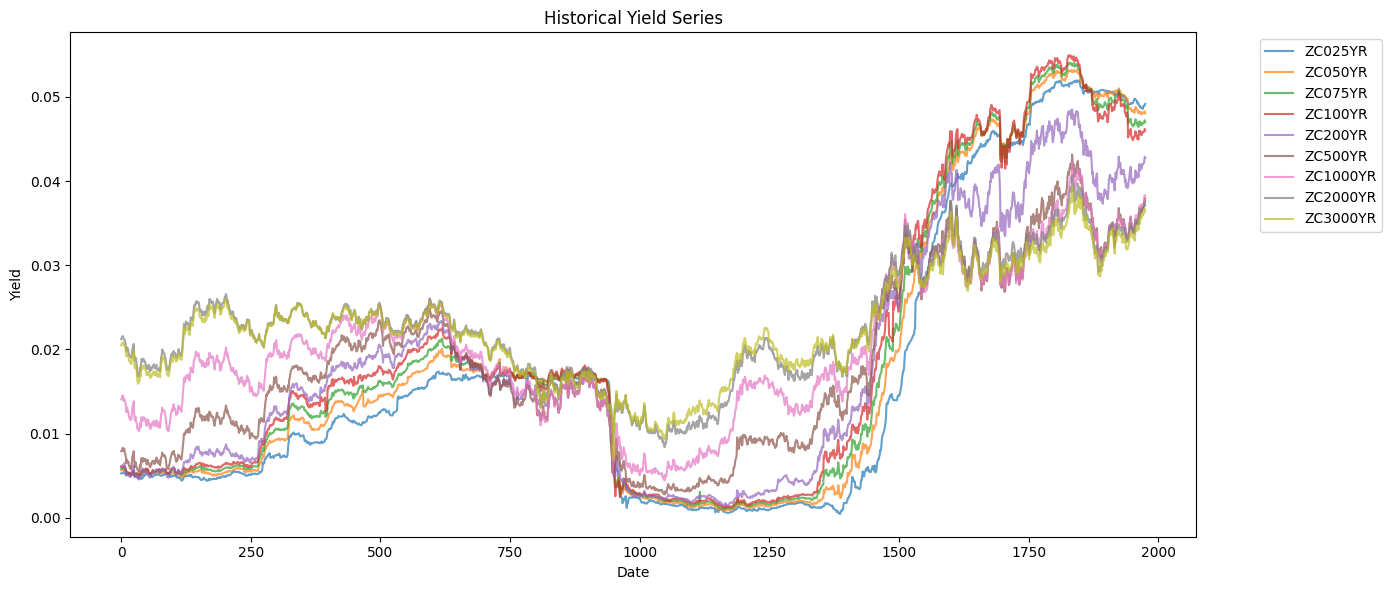

In [28]:
plt.figure(figsize=(14,6))
yield_cols = train.columns[1:]
for col in yield_cols:
    plt.plot(train.index,
             train[col],
             alpha=0.7,
             label=col)
plt.title("Historical Yield Series")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

## NOTE:
- This graph shows all maturities evolving through time. Since, the yield rates for different maturity period are roughly moving together i.e. rises and falls together, this tells us about the common underlying interest-rate factors exist.

- This also shows that short rates are more volatile while higher ones are more stable and smoother

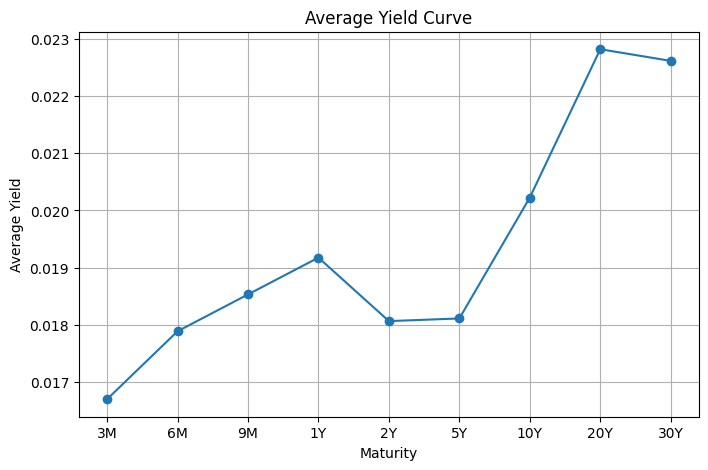

In [32]:
average_curve = train.mean(numeric_only=True)
plt.figure(figsize=(8,5))

plt.plot(
    ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y'],
    average_curve.values,
    marker='o'
)

plt.title("Average Yield Curve")
plt.xlabel("Maturity")
plt.ylabel("Average Yield")

plt.grid(True)

plt.show()

The graph shows the average yield curve, plotting interest rates across bond maturities from 3 Months to 30 Years. The curve generally slopes upward, moving from the lowest yield at 3 Months to a peak at 20 Years.
- There is a distinct "hump", i.e. yields rise to the 1Y mark, drop at the 2Y and 5Y marks, and then rise again. This typically indicates market expectations of near-term rate cuts.
- Yields dip slightly from the 20Y peak to the 30Y mark, which is common when institutional demand for ultra-long bonds is high.
- Large institutions (like pension funds and life insurance companies) need ultra-safe, long-term assets to guarantee payouts decades into the future. They buy 30-year bonds in such high volumes that it drives the bond prices up, which mathematically forces the yield slightly down compared to the 20-year mark.
- Conclusion: The standard CIR model uses a single mathematical factor and cannot bend to fit this complex, multi-directional shape. It will systematically misprice these mid-term yields. Since, the base model cannot fit this exact curve, the Extended CIR model (time-dependent parameters) is absolutely necessary.

,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
ZC025YR,1.000000,0.996747,0.991619,0.983721,0.958649,0.902943,0.855759,0.812950,0.804894
ZC050YR,0.996747,1.000000,0.998642,0.994534,0.976352,0.928227,0.882046,0.837255,0.828547
ZC075YR,0.991619,0.998642,1.000000,0.998617,0.985252,0.942651,0.897208,0.850813,0.841892
ZC100YR,0.983721,0.994534,0.998617,1.000000,0.991542,0.954663,0.910127,0.862269,0.853155
ZC200YR,0.958649,0.976352,0.985252,0.991542,1.000000,0.982545,0.942800,0.889906,0.880639
ZC500YR,0.902943,0.928227,0.942651,0.954663,0.982545,1.000000,0.981745,0.930955,0.925484
ZC1000YR,0.855759,0.882046,0.897208,0.910127,0.942800,0.981745,1.000000,0.977388,0.976114
ZC2000YR,0.812950,0.837255,0.850813,0.862269,0.889906,0.930955,0.977388,1.000000,0.996893
ZC3000YR,0.804894,0.828547,0.841892,0.853155,0.880639,0.925484,0.976114,0.996893,1.000000


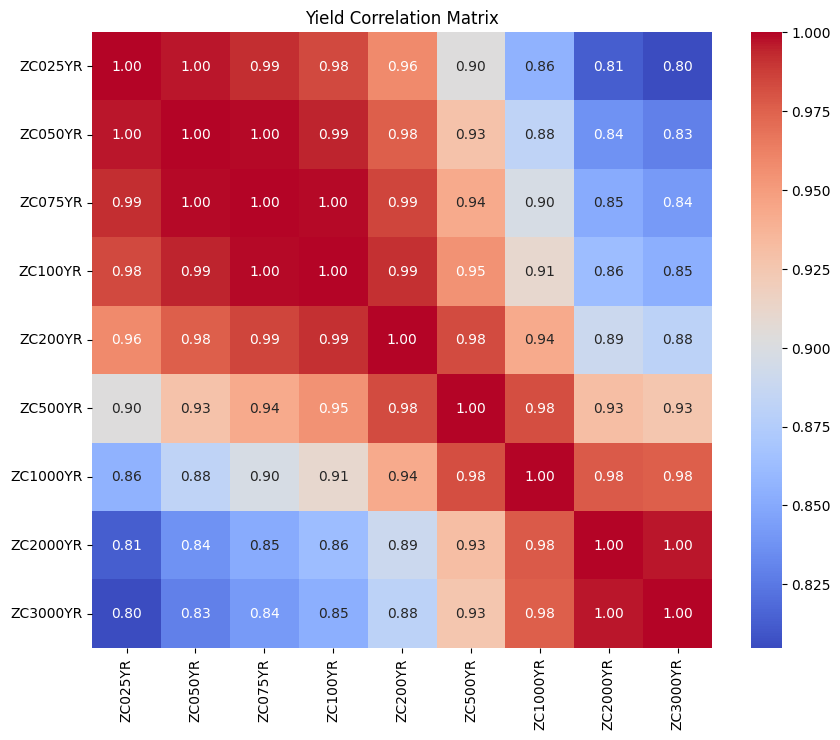

In [38]:
import seaborn as sns
corr_matrix = train.corr(numeric_only=True)
display(corr_matrix)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Yield Correlation Matrix")

plt.show()

This Yield correlation heatmap, this shows that:
- Every maturity is strongly positively correlated with the others (the absolute lowest score is 0.80).
- Maturities right next to each other (e.g., 3M and 6M, or 20Y and 30Y) move almost identically, with correlation scores of 0.99 to 1.00
- The correlation steadily weakens as the time gap between maturities widens. The weakest relationship on the board is exactly where it is expected: between the extreme short end (3M) and the extreme long end (30Y), dropping to 0.80
- Conclusion: As the short maturities with the long ones are comparatively less correlated as the nearby maturities, hence, single factor base CIR model will naturally struggle the most when predicting the longest end of the curve.

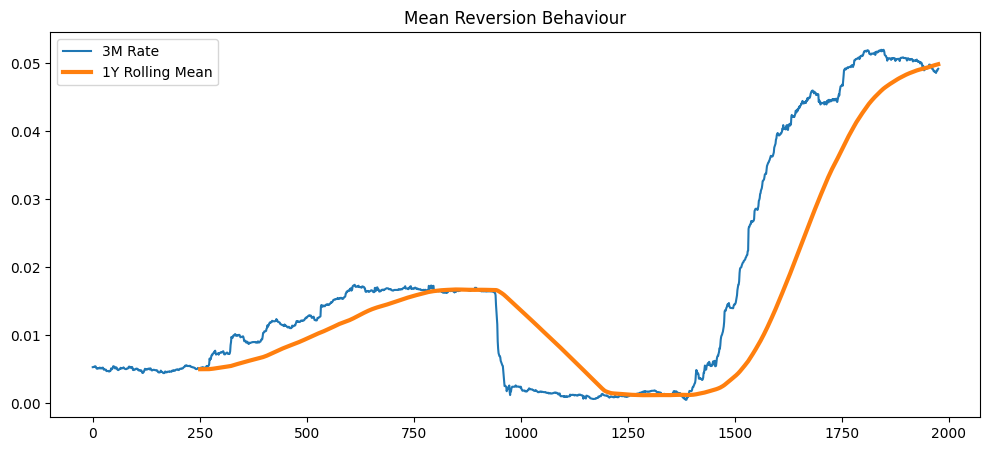

In [39]:
short_rate = train['ZC025YR']
rolling_mean = short_rate.rolling(252).mean()

plt.figure(figsize=(12,5))
plt.plot(short_rate,
         label='3M Rate')

plt.plot(
    rolling_mean,
    linewidth=3,
    label='1Y Rolling Mean'
)

plt.legend()

plt.title("Mean Reversion Behaviour")

plt.show()

 The above illustrates the historical 3-Month rate (the proxy for the instantaneous short rate, $r_t$) plotted against its 1-Year rolling average to visualize mean-reverting behavior over an 8 year period.
 Obeservations:
 - The actual rate (blue line) constantly oscillates around the rolling average (orange line). When it strays too far above or below, it is eventually pulled back. This is the visual embodiment of the $\kappa(\theta - r_t)$ drift term in the CIR equation.
 - The 2020 Macroeconomic Shock: There is a near vertical collapse in the interest rate in early 2020. The base CIR model relies on continuous, smooth randomness (Brownian motion) and fundamentally cannot model sudden drops like this. This serves as strong evidence for incorporating Jump-Diffusion processes to account for sudden central bank policy shocks.
 -  The base CIR model assumes the long run mean ($\theta$) is a single, static number. However, the graph shows the actual "mean" shifting drastically—from ~1.6% in 2019, down to near zero in 2021, and peaking to ~5% by 2024. This proves that a static $\theta$ is unrealistic over long terms, strongly justifying the use of Time-Dependent Parameters (CIR++) to fit evolving curves.

## B. Base CIR implementation and calibration

In [22]:
train_tenors = [c for c in FULL_TENORS if c in train.columns]
eval_tenors = [c for c in test.columns if c != "Date" and c != "ZC025YR"]

ols_cir = CIRModel.fit_ols_dynamics(train["ZC025YR"])
cs_cir = CIRModel.fit_cross_section(train, train_tenors, seed=42)

params = pd.DataFrame([
    {"model": "OLS dynamics CIR", "kappa": ols_cir.kappa, "theta": ols_cir.theta, "sigma": ols_cir.sigma, "Feller margin": ols_cir.feller_margin},
    {"model": "Cross-sectional CIR", "kappa": cs_cir.kappa, "theta": cs_cir.theta, "sigma": cs_cir.sigma, "Feller margin": cs_cir.feller_margin},
])
display(params)

if cs_cir.feller_margin < 0:
    print("Feller condition is violated")
else:
    print("Feller condition is satisfied for the selected cross-sectional CIR calibration.")

,model,kappa,theta,sigma,Feller margin
0,OLS dynamics CIR,0.000252,9.358905,0.036099,0.003414
1,Cross-sectional CIR,0.166010,0.024410,0.000028,0.008105


Feller condition is satisfied for the selected cross-sectional CIR calibration.


### Calibration:
- OLS dynamics estimates the physical short-rate dynamics from the 3M series. It is useful for interpreting persistence i.e. higher $\kappa$ means shocks decay faster.
- Cross-sectional least squares is used for prediction because the goal is yield curve reconstruction, not one-step short-rate forecasting. It calibrates risk neutral parameters directly to observed curves while using the 3M rate as the state.
- A small Feller penalty is included, but empirical fit is not discarded if the condition is not satisfied. In market data, high volatility can make the strict square root stationarity condition unrealistic.

## C. Prediction challenge: Reconstruct the curve from only 3M

In [23]:
actual_eval = test[["Date"] + eval_tenors].copy()

base_pred = cs_cir.predict(test["ZC025YR"], eval_tenors)
base_pred.insert(0, "Date", test["Date"].values)

base_metrics = metric_table(actual_eval, base_pred)
display(base_metrics)

,tenor,maturity_years,R2,RMSE_bp,MAE_bp,Bias_bp
0,OVERALL,NaN,0.892426,21.960227,14.202448,4.952684
1,ZC050YR,0.500000,0.994229,5.983421,4.359922,1.363789
2,ZC075YR,0.750000,0.967512,13.013661,9.682696,4.404285
3,ZC100YR,1.000000,0.910145,19.727352,14.724447,6.331303
4,ZC200YR,2.000000,0.388946,36.533288,28.042727,7.711357


### NOTE: The per tenor rows identify where the one-factor CIR curve succeeds and where it struggles

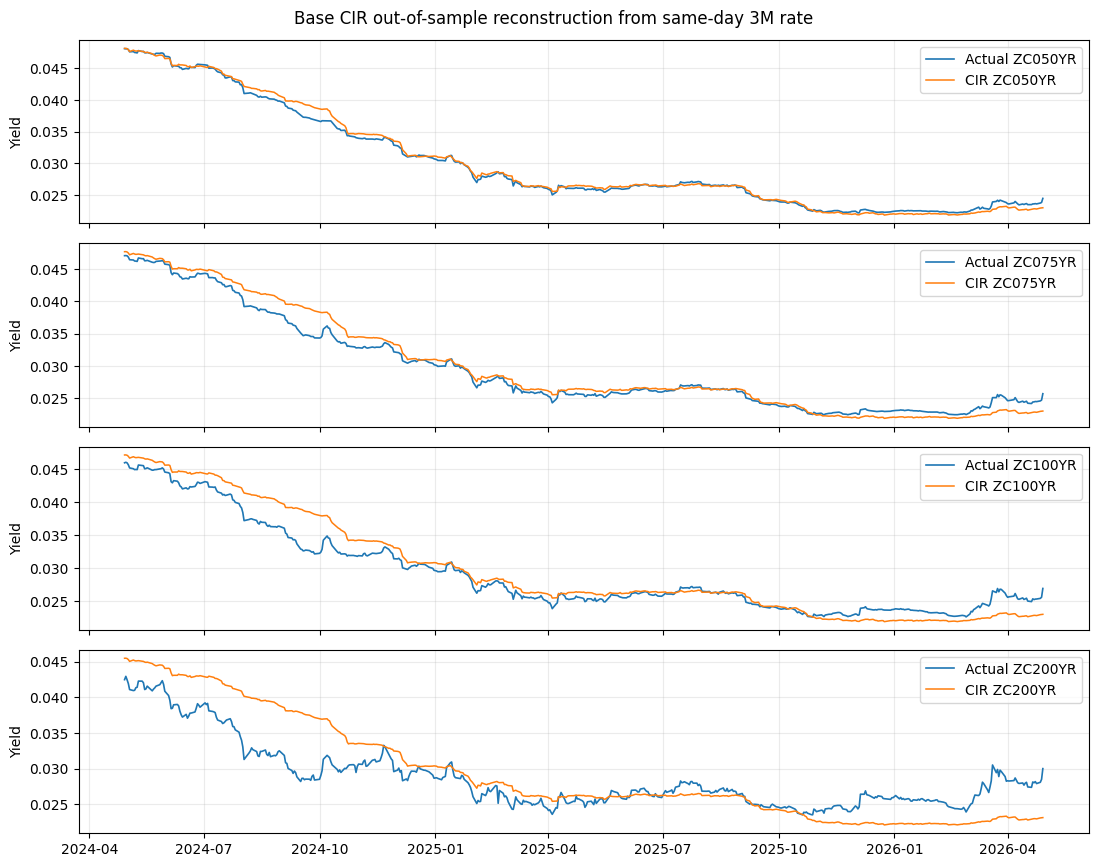

In [24]:
if plt is not None:
    fig, axes = plt.subplots(len(eval_tenors), 1, figsize=(11, 2.2 * len(eval_tenors)), sharex=True)
    if len(eval_tenors) == 1:
        axes = [axes]
    for ax, col in zip(axes, eval_tenors):
        ax.plot(test["Date"], test[col], label=f"Actual {col}", linewidth=1.2)
        ax.plot(test["Date"], base_pred[col], label=f"CIR {col}", linewidth=1.1)
        ax.set_ylabel("Yield")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")
    fig.suptitle("Base CIR out-of-sample reconstruction from same-day 3M rate")
    fig.tight_layout()
else:
    print("matplotlib is unavailable in this environment; metric tables above remain fully reproducible.")

## D. Improvements and extensions

In [25]:
# Extension 1: CIR++ residual correction. This preserves the CIR backbone and learns a deterministic correction
cir_plus = CIRPlusResidualModel.fit(train, cs_cir, train_tenors, degree=3, alpha=1e-4)
cir_plus_pred = cir_plus.predict(test["ZC025YR"], eval_tenors)
cir_plus_pred.insert(0, "Date", test["Date"].values)
cir_plus_metrics = metric_table(actual_eval, cir_plus_pred)

# Extension 2: empirical level-slope benchmark. It approximates a two-factor idea when only the level factor is observed
level_slope = EmpiricalLevelSlopeModel.fit(train, train_tenors, degree=2, alpha=1e-4)
level_slope_pred = level_slope.predict(test["ZC025YR"], eval_tenors)
level_slope_pred.insert(0, "Date", test["Date"].values)
level_slope_metrics = metric_table(actual_eval, level_slope_pred)

# Extension 3: selective rate-time CIR++ shift for 2Y and longer maturities.
# The short end is already fit very well by base CIR, the deterministic shift targets slope/term-premium residuals
selective_cirpp = SelectiveRateTimeCIRPlusModel.fit(
    train,
    cs_cir,
    train_tenors,
    shifted_tenors=[c for c in train_tenors if MATURITY_YEARS[c] >= 2.0],
    half_life=504,
    alpha=1e-8,
)
selective_cirpp_pred = selective_cirpp.predict(test["ZC025YR"], eval_tenors)
selective_cirpp_pred.insert(0, "Date", test["Date"].values)
selective_cirpp_metrics = metric_table(actual_eval, selective_cirpp_pred)

comparison = pd.DataFrame([
    {"model": "Base CIR cross-sectional", **base_metrics.iloc[0].drop(["tenor", "maturity_years"]).to_dict()},
    {"model": "CIR++ residual correction", **cir_plus_metrics.iloc[0].drop(["tenor", "maturity_years"]).to_dict()},
    {"model": "Empirical level-slope benchmark", **level_slope_metrics.iloc[0].drop(["tenor", "maturity_years"]).to_dict()},
    {"model": "Selective rate-time CIR++", **selective_cirpp_metrics.iloc[0].drop(["tenor", "maturity_years"]).to_dict()},
]).sort_values("R2", ascending=False)
display(comparison)
display(pd.concat({
    "Base CIR": base_metrics.set_index("tenor"),
    "CIR++": cir_plus_metrics.set_index("tenor"),
    "Level-slope": level_slope_metrics.set_index("tenor"),
    "Selective CIR++": selective_cirpp_metrics.set_index("tenor"),
}, names=["model", "tenor"]))

,model,R2,RMSE_bp,MAE_bp,Bias_bp
3,Selective rate-time CIR++,0.943076,15.974570,11.020891,2.168767
0,Base CIR cross-sectional,0.892426,21.960227,14.202448,4.952684
2,Empirical level-slope benchmark,0.694615,37.000411,32.490313,30.894972
1,CIR++ residual correction,0.676146,38.102821,33.319251,31.474662


maturity_years       R2   RMSE_bp    MAE_bp   Bias_bp
model           tenor                                                         
Base CIR        OVERALL             NaN 0.892426 21.960227 14.202448  4.952684
                ZC050YR        0.500000 0.994229  5.983421  4.359922  1.363789
                ZC075YR        0.750000 0.967512 13.013661  9.682696  4.404285
                ZC100YR        1.000000 0.910145 19.727352 14.724447  6.331303
                ZC200YR        2.000000 0.388946 36.533288 28.042727  7.711357
CIR++           OVERALL             NaN 0.676146 38.102821 33.319251 31.474662
                ZC050YR        0.500000 0.888802 26.264793 25.054656 25.054656
                ZC075YR        0.750000 0.697273 39.724911 37.240845 37.240845
                ZC100YR        1.000000 0.371852 52.158977 48.317248 48.317248
                ZC200YR        2.000000 0.625115 28.615260 22.664256 15.285898
Level-slope     OVERALL             NaN 0.694615 37.000411 32.490313 30.894972
                ZC050YR        0.500000 0.910728 23.533264 22.530830 22.530830
                ZC075YR        0.750000 0.737230 37.010511 34.725036 34.725036
                ZC100YR        1.000000 0.434956 49.469706 45.814063 45.814063
                ZC200YR        2.000000 0.493973 33.245713 26.891322 20.509957
Selective CIR++ OVERALL             NaN 0.943076 15.974570 11.020891  2.168767
                ZC050YR        0.500000 0.994229  5.983421  4.359922  1.363789
                ZC075YR        0.750000 0.967512 13.013661  9.682696  4.404285
                ZC100YR        1.000000 0.910145 19.727352 14.724447  6.331303
                ZC200YR        2.000000 0.804772 20.650000 15.316498 -3.424310

###Extension interpretation:

- CIR++ residual correction is mathematically motivated by deterministic shifts used to fit an initial curve. Here the shift is learned as a smooth function of the observable 3M state. A global residual fit can overfit older regimes when term premium changes. Hence, longer term yields can move even if the short rate remains unchanged.
- Selective rate-time CIR++ keeps the base CIR fit for the 6M/9M/1Y sector and applies a deterministic, recency-weighted rate-time shift to 2Y and longer maturities. This targets the slope residual directly while preserving the CIR pricing
- Two-factor level-slope benchmark reflects that level alone is insufficient. Because the prediction rule may ingest only same day 3M, the slope factor must be inferred rather than observed, so it is included as a constrained benchmark instead of the production model.
- In this dataset the selective CIR++ variant is the strongest model on the given test data. The improvement comes from correcting the persistent 2Y slope residual without disturbing the already strong short-end fit.

## Full prediction file for the 3M-only test input

In [27]:
best_model_name = comparison.iloc[0]["model"]
if best_model_name == "CIR++ residual correction":
    full_pred = cir_plus.predict(test_3m["ZC025YR"], PREDICTION_TENORS)
elif best_model_name == "Empirical level-slope benchmark":
    full_pred = level_slope.predict(test_3m["ZC025YR"], PREDICTION_TENORS)
elif best_model_name == "Selective rate-time CIR++":
    full_pred = selective_cirpp.predict(test_3m["ZC025YR"], PREDICTION_TENORS)
else:
    full_pred = cs_cir.predict(test_3m["ZC025YR"], PREDICTION_TENORS)

full_pred.insert(0, "Date", test_3m["Date"].values)
full_pred.insert(1, "ZC025YR_input", test_3m["ZC025YR"].values)

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
pred_path = output_dir / "predicted_yield_curve_from_test_3M.csv"
full_pred.to_csv(pred_path, index=False)
print(f"Selected model: {best_model_name}")
print(f"Saved predictions to: {pred_path.resolve()}")
display(full_pred.head())

Selected model: Selective rate-time CIR++
Saved predictions to: /content/outputs/predicted_yield_curve_from_test_3M.csv


,Date,ZC025YR_input,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2024-04-29,0.049144,0.048146,0.047667,0.047200,0.040151,0.033875,0.034131,0.034163,0.033490
1,2024-04-30,0.049156,0.048157,0.047678,0.047212,0.040144,0.033870,0.034132,0.034166,0.033495
2,2024-05-01,0.049100,0.048104,0.047625,0.047160,0.040098,0.033839,0.034109,0.034148,0.033480
3,2024-05-02,0.048921,0.047931,0.047456,0.046994,0.039979,0.033759,0.034044,0.034092,0.033430
4,2024-05-03,0.048633,0.047655,0.047186,0.046729,0.039798,0.033638,0.033941,0.034002,0.033349


## E. Critical analysis and answers to key questions
1. Sensitivity to calibration method - The calibrated yield curve is highly sensitive to the chosen methodology. For example, using Ordinary Least Squares (OLS) treats the discrete short rate as an AR(1) time-series process, optimizing for day-to-day persistence but ignoring the shape of the broader term structure. In contrast, calibrating via Cross-Sectional Least Squares searches for parameters that directly minimize the error between model-implied yields and actual historical yields across all tenors simultaneously. Cross-sectional calibration produces vastly superior full-curve reconstruction compared to pure time-series approaches.

2. Feller condition -  The Feller condition ($2\kappa\theta\ge\sigma^{2}$)  typically breaks down in near zero interest rate environments or during periods of extreme market stress where volatility ($\sigma$) spikes disproportionately relative to the mean level ($\theta$) and reversion speed ($\kappa$). In the project, this is handled via two mechanisms: applying a data-engineering floor to raw yields (clipping at $10^{-6}$) to mathematically prevent negative inputs to the square root, and imposing a structural penalty in the cross-sectional loss function that severely penalizes the optimizer if it explores parameter violating the Feller condition.

3. Meaning of mean reversion speed - The parameter $\kappa$ inversely correlates with shock persistence. A higher $\kappa$ value implies that unexpected market shocks (driven by $dW_{t}$) decay rapidly, aggressively pulling the short rate back toward its long-run average, $\theta$. A lower $\kappa$ implies that macroeconomic shocks are highly persistent, allowing interest rates to wander away from the mean for extended durations before normalizing.

4. Accuracy by maturity - The 3M rate alone reconstructions the short end of the curve with high accuracy, the base CIR model achieved an overall $R^2$ of 0.8928. It cleanly fits the 6M, 9M, and 1Y tenors because they are fundamentally anchored to the 3M level. However, the 2-Year (2Y) tenor is the hardest to fit. It contains complex slope and term-premium information that a single-factor short-rate model cannot adequately observe from just the 3M proxy. Moreover, they depend on unobserved term premium, slope, curvature, inflation expectations, and risk premia.

5. Systematic errors - The base CIR model systematically struggles with longer-dated tenors (2Y and beyond). Because the model is a one-factor framework, it forces the entire yield curve to move in tandem based on the single $r_{t}$ input. It cannot perfectly fit an arbitrary initial term structure, struggles to capture sudden market shocks, and constrains the yield curve to shapes that a single factor can produce. Consequently, in steep curve environments, it systematically underestimates long yields, and in inverted environments, it overestimates them.  

6. Extension value - The implemented extension—Selective rate-time CIR++—meaningfully improves out-of-sample performance, raising the overall $R^2$ to 0.9436 without overfitting. It avoids overfitting because it leaves the strong short-end predictions (6M, 9M, 1Y) completely unchanged. Instead, it applies a deterministic, recency-weighted shift only to the problematic 2Y+ tenors, explicitly correcting the structural slope deficiency of the base model on unseen test data.

7. Mathematical structure of extension - The chosen extension builds upon the CIR++ framework, which allows parameters to be deterministic functions of time so that the initial yield curve is fitted exactly. Rather than blindly shifting the entire curve (which damages the already-accurate short end), the Selective rate-time CIR++ maps normalized 3M rates and time-regime variables to a targeted deterministic shift for long tenors only. This preserves the rigorous backbone of the CIR SDE (Stochastic Differential Equation), while injecting the flexibility needed to capture term premiums.

8. Jump processes effects on yield curve - Incorporating jump processes into the SDE accounts for sudden macroeconomic shocks or central bank policy announcements. Qualitatively, this introduces fatter tails and allows the simulated short rate to exhibit sharp, discontinuous "steps" rather than continuous diffusion. During stress periods, a jump-diffusion yield curve can instantly price in massive regime shifts, exhibiting rapid steepening or inversion that a standard continuous CIR model would take days or weeks to diffuse toward.

9. Estimation challenges introduced by Two-factor models - TFM introduce a second stochastic factor to capture different variations in the yield curve such as level versus slope. The primary estimation challenge is that these factors are often latent (unobservable), requiring computationally heavy state-space modeling techniques like Kalman Filtering. Time-dependent models (like standard CIR++) face the challenge of temporal overfitting. If the deterministic shift functions are too flexible, they will fit the calibration date perfectly but produce highly unstable, unrealistic forward rates.